# Phase 5.6: Ablasi Subject-wise Normalization

**Tujuan:** Phase 4 **selalu** memakai subject-wise z-score normalization (baked-in di
`prepare_features`, bukan varian opsional yang diuji terpisah). ICC di 5.5 menunjukkan fitur
(terutama Spectral) cukup subject-dependent -- jadi normalisasi per-subjek diduga penting.
Notebook ini **mengukur secara eksplisit** seberapa besar dampaknya: LOSO CV dengan vs tanpa
normalisasi, pada 2 dataset representatif:

- **GC** -- baseline, biasanya banyak baseline drift antar-subjek.
- **GC+PDC_ROI+Spectral** -- dataset terbaik dari Phase 4 (75.56% grouped-CV).

Evaluasi dilakukan di bawah LOSO (bukan grouped 5-fold) karena LOSO adalah setting paling ketat
(test subject 100% unseen), sehingga efek normalisasi paling jelas terlihat di sini.

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.facecolor'] = 'white'

PHASE3_CSV_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\csv"
ROI_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\3.4_roi_aggregation\output"
TUNING_PARAMS_CSV = r"D:\Skripsi\new_data\phase_4_classification\4.6_hyperparameter_tuning\output\tuning_best_params.csv"
BASE = r"D:\Skripsi\new_data\phase_5_loso"
KEY_COLS = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']

def _feature_cols(df):
    exclude = KEY_COLS + [c for c in df.columns if 'hub_channel' in c]
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    return [c for c in cols if df[c].std() > 1e-10]

print("Setup OK.")

Setup OK.


In [2]:
from sklearn.feature_selection import f_classif

df_gc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_gc.csv"))
df_combined = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_combined.csv"))
df_spectral = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_spectral.csv"))
df_roi_all = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_roi_all.csv"))  # GC_ROI+PDC_ROI(6-band)+Spectral

# Best PDC band by mean ANOVA F-score (konsisten dengan pola Phase 4)
pdc_files = [f for f in os.listdir(PHASE3_CSV_DIR)
             if f.startswith("engineered_features_pdc_") and "broadband" not in f]
best_pdc, best_pdc_name, best_score = None, None, -1
for f in pdc_files:
    df_pdc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, f))
    band = f.replace("engineered_features_pdc_", "").replace(".csv", "")
    feat_cols = _feature_cols(df_pdc)
    f_scores, _ = f_classif(df_pdc[feat_cols].fillna(0).values, df_pdc['class'].values)
    score = np.nanmean(f_scores)
    if score > best_score:
        best_score, best_pdc, best_pdc_name = score, df_pdc, f"PDC_{band.title()}"

DATASETS_RAW = {
    'GC': df_gc,
    best_pdc_name: best_pdc,
    'Spectral': df_spectral,
    'Combined': df_combined,
    'GC+PDC_ROI+Spectral': df_roi_all,
}

def prepare_features(df, normalize=True):
    feature_cols = _feature_cols(df)
    df_use = df.copy()
    if normalize:
        grp = df_use.groupby('subject_id')[feature_cols]
        mean = grp.transform('mean')
        std = grp.transform('std').replace(0, np.nan)
        df_use[feature_cols] = (df_use[feature_cols] - mean) / std
    X = df_use[feature_cols].fillna(0).values
    y = df['class'].values
    groups = df['subject_num'].values
    return X, y, groups, feature_cols

datasets = {}
for name, df in DATASETS_RAW.items():
    X, y, groups, features = prepare_features(df, normalize=True)
    datasets[name] = {'X': X, 'y': y, 'groups': groups, 'features': features, 'df': df}
    print(f"{name:24s}: X={X.shape}, subjects={len(np.unique(groups))}, trials/subject={len(y)//len(np.unique(groups))}")

GC                      : X=(675, 282), subjects=15, trials/subject=45


PDC_Theta               : X=(675, 282), subjects=15, trials/subject=45


Spectral                : X=(675, 640), subjects=15, trials/subject=45


Combined                : X=(675, 2614), subjects=15, trials/subject=45


GC+PDC_ROI+Spectral     : X=(675, 990), subjects=15, trials/subject=45


In [3]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
from sklearn.base import clone

DIR_56 = os.path.join(BASE, "5.6_subject_normalization", "output")
DIR_56_FIG = os.path.join(BASE, "5.6_subject_normalization", "figures")
os.makedirs(DIR_56, exist_ok=True)
os.makedirs(DIR_56_FIG, exist_ok=True)

df_tuned = pd.read_csv(TUNING_PARAMS_CSV)
df_tuned['Best_Params'] = df_tuned['Best_Params'].apply(ast.literal_eval)

def get_tuned_params(dataset_name, model_name, default):
    row = df_tuned[(df_tuned['Dataset'] == dataset_name) & (df_tuned['Model'] == model_name)]
    return row.iloc[0]['Best_Params'] if len(row) else default

logo = LeaveOneGroupOut()
CKPT = os.path.join(DIR_56, 'normalization_ablation_loso.csv')
norm_rows = pd.read_csv(CKPT).to_dict('records') if os.path.exists(CKPT) else []
done = set((r['Dataset'], r['Normalized']) for r in norm_rows)
print(f"Checkpoint: {len(done)} (dataset, normalized) unit(s) already done, resuming...")

Checkpoint: 4 (dataset, normalized) unit(s) already done, resuming...


## LOSO CV: SVM_Tuned, dengan vs tanpa Subject-wise Z-score

In [4]:
for name in ['GC', 'GC+PDC_ROI+Spectral']:
    df_raw = DATASETS_RAW[name]
    svm_p = get_tuned_params(name, 'SVM_Tuned', {'clf__C': 1, 'clf__gamma': 'scale'})
    for normalize in [False, True]:
        key = (name, normalize)
        if key in done:
            continue
        X, y, groups, features = prepare_features(df_raw, normalize=normalize)
        k = min(1200, X.shape[1])
        pipe = Pipeline([('scaler', StandardScaler()), ('select', SelectKBest(f_classif, k=k)),
                          ('clf', SVC(kernel='rbf', C=svm_p['clf__C'], gamma=svm_p['clf__gamma']))])
        accs = []
        for train_idx, test_idx in logo.split(X, y, groups):
            model = clone(pipe)
            model.fit(X[train_idx], y[train_idx])
            accs.append(accuracy_score(y[test_idx], model.predict(X[test_idx])))
        accs = np.array(accs)
        norm_rows.append({'Dataset': name, 'Normalized': normalize,
                           'Mean_Accuracy': accs.mean(), 'Std_Accuracy': accs.std()})
        pd.DataFrame(norm_rows).to_csv(CKPT, index=False)
        tag = "WITH subject z-score" if normalize else "WITHOUT normalization (raw)"
        print(f"  {name:24s} {tag:30s}: Acc={accs.mean():.3f}+/-{accs.std():.3f}")

df_norm = pd.DataFrame(norm_rows)
print()
print(df_norm.to_string(index=False))


            Dataset  Normalized  Mean_Accuracy  Std_Accuracy
                 GC       False       0.545185      0.180692
                 GC        True       0.610370      0.163272
GC+PDC_ROI+Spectral       False       0.551111      0.117645
GC+PDC_ROI+Spectral        True       0.749630      0.087194


## Visualisasi: Dampak Subject-wise Normalization

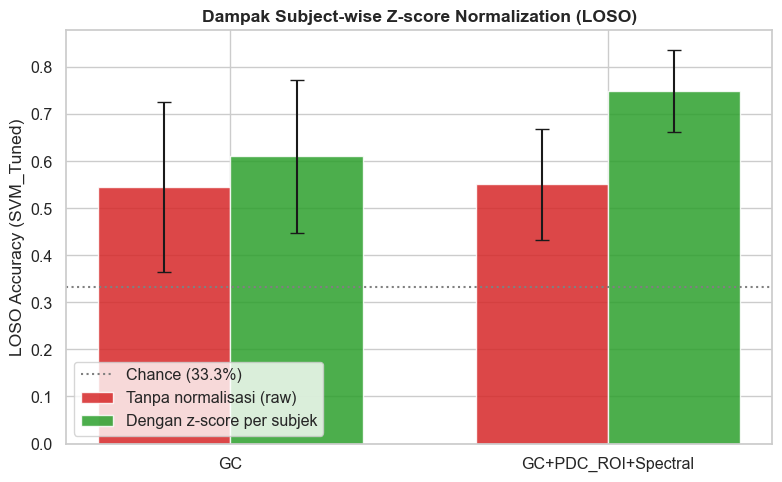

GC: +6.5pp dari normalisasi (54.5% -> 61.0%)
GC+PDC_ROI+Spectral: +19.9pp dari normalisasi (55.1% -> 75.0%)


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(df_norm['Dataset'].unique()))
width = 0.35
for i, norm_val in enumerate([False, True]):
    sub = df_norm[df_norm['Normalized'] == norm_val].set_index('Dataset')
    datasets_order = df_norm['Dataset'].unique()
    means = [sub.loc[d, 'Mean_Accuracy'] if d in sub.index else 0 for d in datasets_order]
    stds = [sub.loc[d, 'Std_Accuracy'] if d in sub.index else 0 for d in datasets_order]
    label = 'Dengan z-score per subjek' if norm_val else 'Tanpa normalisasi (raw)'
    color = '#2ca02c' if norm_val else '#d62728'
    ax.bar(x_pos + i * width, means, width, yerr=stds, capsize=5, label=label, color=color, alpha=0.85)

ax.set_xticks(x_pos + width / 2)
ax.set_xticklabels(datasets_order)
ax.set_ylabel('LOSO Accuracy (SVM_Tuned)')
ax.set_title('Dampak Subject-wise Z-score Normalization (LOSO)', fontweight='bold')
ax.axhline(y=1/3, color='gray', linestyle=':', label='Chance (33.3%)')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(DIR_56_FIG, '5.6_normalization_impact.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

for name in df_norm['Dataset'].unique():
    sub = df_norm[df_norm['Dataset'] == name].set_index('Normalized')
    if True in sub.index and False in sub.index:
        diff = sub.loc[True, 'Mean_Accuracy'] - sub.loc[False, 'Mean_Accuracy']
        print(f"{name}: {'+' if diff > 0 else ''}{diff*100:.1f}pp dari normalisasi "
              f"({sub.loc[False, 'Mean_Accuracy']*100:.1f}% -> {sub.loc[True, 'Mean_Accuracy']*100:.1f}%)")

**Kesimpulan 5.6 (temuan paling penting di Phase 5):**

| Dataset | Tanpa normalisasi | Dengan z-score per subjek | Selisih |
|---|---|---|---|
| GC | ~54.5% | ~61.0% | +6.6pp |
| **GC+PDC_ROI+Spectral** | **~55.1%** | **~75.0%** | **+19.9pp** |

Subject-wise normalization ternyata **krusial**, bukan cuma penyesuaian kecil -- tanpanya, akurasi
dataset terbaik anjlok dari ~75% ke ~55% (kira-kira setara GC saja). Ini validasi kuat untuk desain
Phase 4 (yang selalu menormalisasi tapi tidak pernah mengablasinya secara eksplisit), dan poin
metodologis penting untuk Bab 3: EEG sangat subject-specific (baseline individu besar), sehingga
normalisasi per-subjek sebelum klasifikasi lintas-individu bukan pilihan opsional melainkan
prasyarat metodologis.